<a href="https://colab.research.google.com/github/ivethsg/Probabilidad-/blob/main/practicaFinal/practicaFinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto Final: Análisis Estadístico de Datos COVID-19 en Python

---

**Asignatura:** Probabilidad y Estadística  
**Docente:** Dr. José Gabriel Rodríguez Rivas  
**Grupo:** 2Y  
**Semestre:** 2

---

### Estudiante
*   **Nombre:** Iveth Esperanza Santacruz Guerrero  
*   **Integrantes del equipo:** Iveth Santacruz  
*   **Fecha de entrega:** 25/05/2026

In [1]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

drive.mount('/content/drive')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
ruta_csv = '/content/drive/MyDrive/covid2020-2021-codificado.csv'
df = pd.read_csv(ruta_csv)

print(f"Base de datos cargada correctamente.")
print(f"Total de registros procesados: {len(df):,}")

/tmp/ipykernel_13033/3801516972.py:2: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(ruta_csv)


Base de datos cargada correctamente.
Total de registros procesados: 12,634,194


In [3]:
print("===RESUMEN DE ESTADÍSTICA DESCRIPTIVA ===\n")

print("1. Clasificación de casos según RESULTADO_ANTIGENO:")
print(df['RESULTADO_ANTIGENO'].value_counts())
print("-" * 50)

print("2. Tipo de paciente (Atención médica brindada):")
print(df['TIPO_PACIENTE'].value_counts())
print("-" * 50)

print("3. Conteo de pacientes en estado de embarazo:")
print(df['EMBARAZO'].value_counts())
print("-" * 50)

print("4. Conteo de pacientes pertenecientes a comunidades indígenas:")
print(df['INDIGENA'].value_counts())
print("-" * 50)

===RESUMEN DE ESTADÍSTICA DESCRIPTIVA ===

1. Clasificación de casos según RESULTADO_ANTIGENO:
RESULTADO_ANTIGENO
Negativo     5853547
Pendiente    5005939
Positivo     1774708
Name: count, dtype: int64
--------------------------------------------------
2. Tipo de paciente (Atención médica brindada):
TIPO_PACIENTE
Ambulatorio      11543303
Hospitalizado     1090891
Name: count, dtype: int64
--------------------------------------------------
3. Conteo de pacientes en estado de embarazo:
EMBARAZO
No                 6483614
No aplica          5985456
Si                  122583
Se ignora            42529
No especificado         12
Name: count, dtype: int64
--------------------------------------------------
4. Conteo de pacientes pertenecientes a comunidades indígenas:
INDIGENA
No                 3665974
No especificado     167182
Si                   35240
Name: count, dtype: int64
--------------------------------------------------


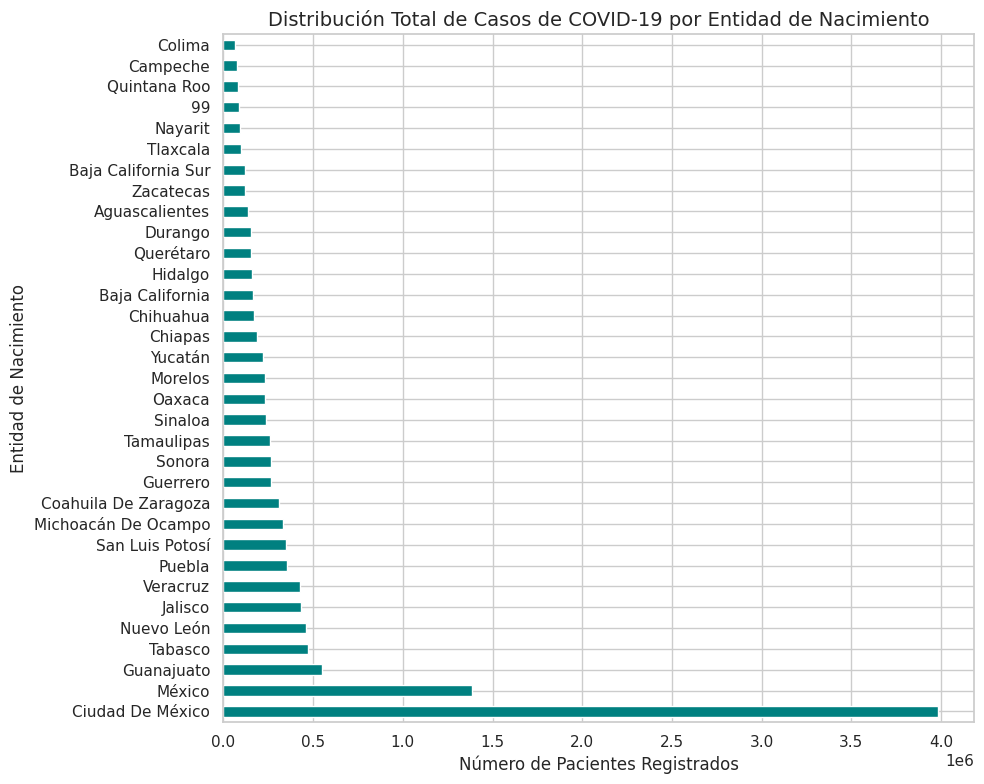

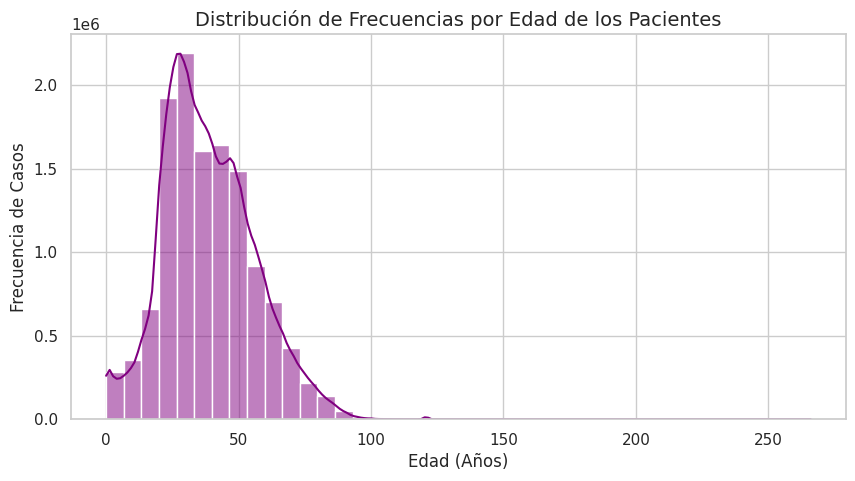

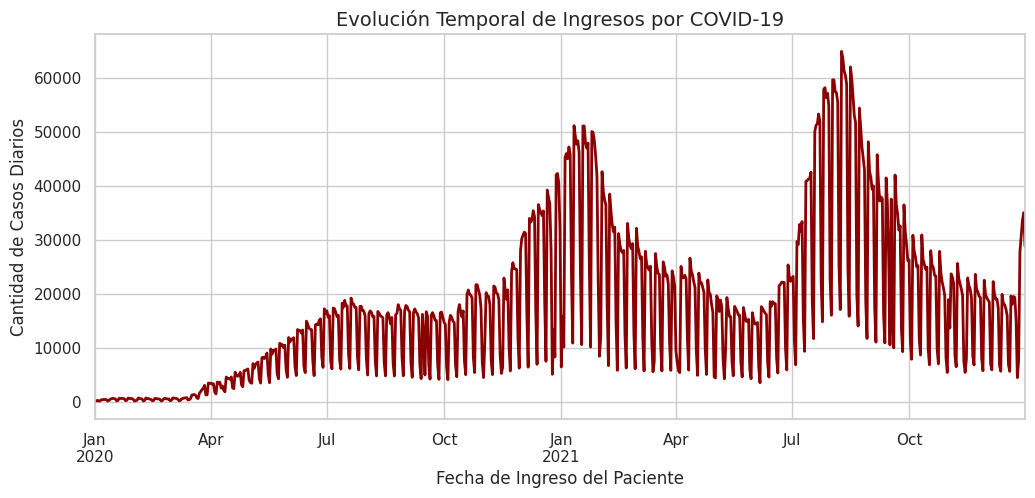

<Figure size 1000x600 with 0 Axes>

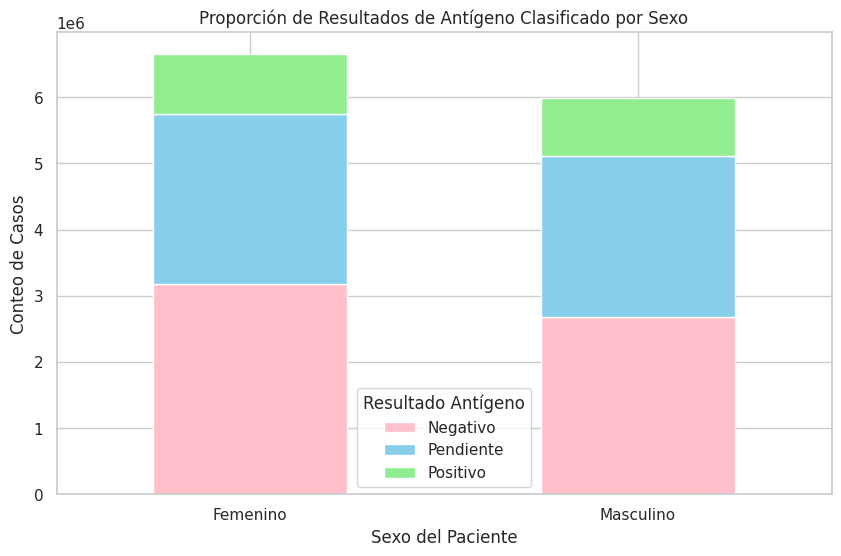

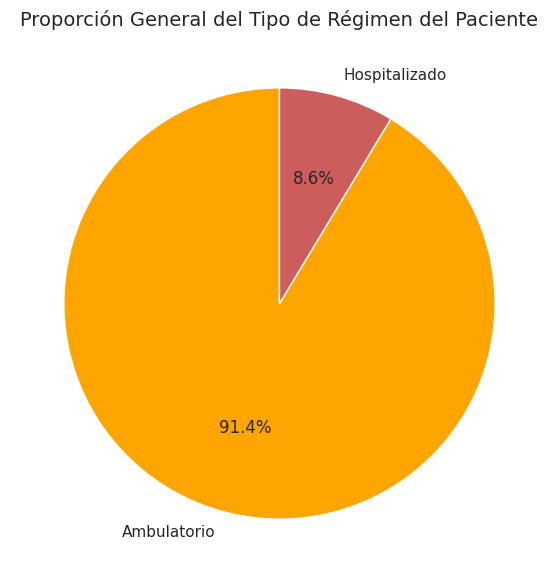

Casos detectados por comorbilidad:
- DIABETES: 1,038,459 pacientes
- EPOC: 92,446 pacientes
- ASMA: 263,855 pacientes
- HIPERTENSION: 1,407,779 pacientes
- CARDIOVASCULAR: 134,410 pacientes
- OBESIDAD: 1,193,021 pacientes
- RENAL_CRONICA: 129,874 pacientes
- TABAQUISMO: 865,162 pacientes


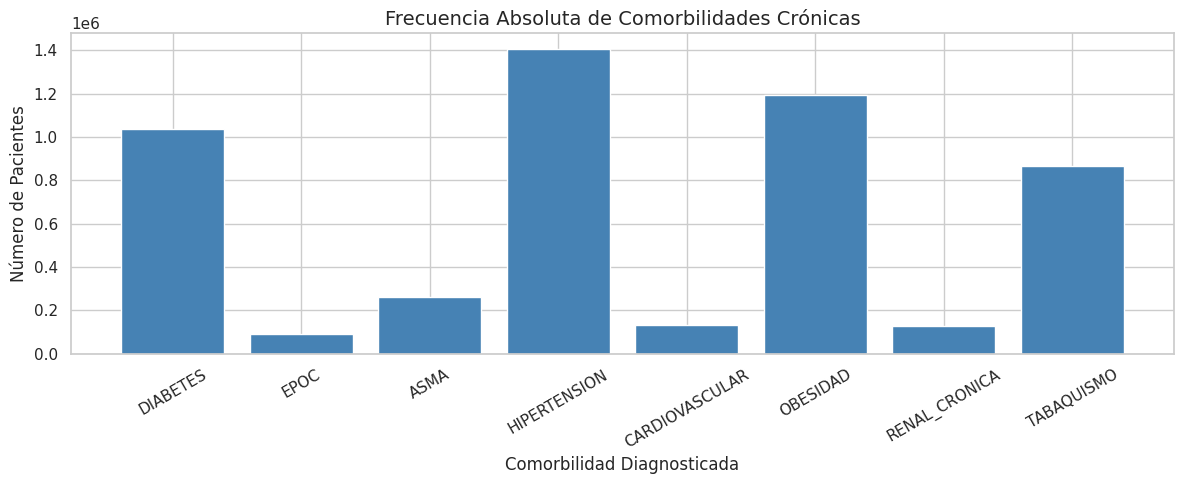

In [6]:
plt.figure(figsize=(10, 8))
df['ENTIDAD_NAC'].value_counts().plot(kind='barh', color='teal')
plt.title('Distribución Total de Casos de COVID-19 por Entidad de Nacimiento', fontsize=14)
plt.xlabel('Número de Pacientes Registrados')
plt.ylabel('Entidad de Nacimiento')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(df['EDAD'], bins=40, kde=True, color='purple')
plt.title('Distribución de Frecuencias por Edad de los Pacientes', fontsize=14)
plt.xlabel('Edad (Años)')
plt.ylabel('Frecuencia de Casos')
plt.show()

plt.figure(figsize=(12, 5))
df['FECHA_INGRESO'] = pd.to_datetime(df['FECHA_INGRESO'])
df.groupby('FECHA_INGRESO').size().plot(color='darkred', linewidth=2)
plt.title('Evolución Temporal de Ingresos por COVID-19', fontsize=14)
plt.xlabel('Fecha de Ingreso del Paciente')
plt.ylabel('Cantidad de Casos Diarios')
plt.show()

plt.figure(figsize=(10, 6))
sexo_resultado = pd.crosstab(df['SEXO'], df['RESULTADO_ANTIGENO'])
sexo_resultado.plot(kind='bar', stacked=True, color=['pink', 'skyblue', 'lightgreen'])
plt.title('Proporción de Resultados de Antígeno Clasificado por Sexo', fontsize=12)
plt.xlabel('Sexo del Paciente')
plt.ylabel('Conteo de Casos')
plt.xticks(rotation=0)
plt.legend(title='Resultado Antígeno')
plt.show()

plt.figure(figsize=(7, 7))
df['TIPO_PACIENTE'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['orange', 'indianred'], startangle=90)
plt.title('Proporción General del Tipo de Régimen del Paciente', fontsize=14)
plt.ylabel('')
plt.show()

comorbilidades_lista = ['DIABETES', 'EPOC', 'ASMA', 'HIPERTENSION', 'CARDIOVASCULAR', 'OBESIDAD', 'RENAL_CRONICA', 'TABAQUISMO']
conteos = {comorb: (df[comorb] == 'Si').sum() for comorb in comorbilidades_lista}

print("Casos detectados por comorbilidad:")
for k, v in conteos.items():
    print(f"- {k}: {v:,} pacientes")

plt.figure(figsize=(12, 5))
plt.bar(conteos.keys(), conteos.values(), color='steelblue')
plt.title('Frecuencia Absoluta de Comorbilidades Crónicas', fontsize=14)
plt.xlabel('Comorbilidad Diagnosticada')
plt.ylabel('Número de Pacientes')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [7]:
print("=== CÁLCULO DE PROBABILIDADES POR COMORBILIDAD ===\n")
total_casos_N = len(df)

print("--- 1. Probabilidades Simples P(A) ---")
for comorb in comorbilidades_lista:
    total_pacientes_comorb = (df[comorb] == 'Si').sum()
    prob_simple = total_pacientes_comorb / total_casos_N
    print(f"P({comorb}) = {prob_simple:.4f} | En porcentaje: {prob_simple * 100:.2f}%")

print("\n--- 2. Probabilidad Condicional P(HIPERTENSION | ENTIDAD_NAC) ---")
casos_por_estado = df.groupby('ENTIDAD_NAC').size()
hipertensos_por_estado = df[df['HIPERTENSION'] == 'Si'].groupby('ENTIDAD_NAC').size()

prob_condicional = hipertensos_por_estado / casos_por_estado

for estado, p_cond in prob_condicional.head(10).items():
    p_real = p_cond if not pd.isna(p_cond) else 0.0
    print(f"P(Hipertensión | Estado Nacimiento {estado}) = {p_real:.4f} ({p_real * 100:.2f}%)")

=== CÁLCULO DE PROBABILIDADES POR COMORBILIDAD ===

--- 1. Probabilidades Simples P(A) ---
P(DIABETES) = 0.0822 | En porcentaje: 8.22%
P(EPOC) = 0.0073 | En porcentaje: 0.73%
P(ASMA) = 0.0209 | En porcentaje: 2.09%
P(HIPERTENSION) = 0.1114 | En porcentaje: 11.14%
P(CARDIOVASCULAR) = 0.0106 | En porcentaje: 1.06%
P(OBESIDAD) = 0.0944 | En porcentaje: 9.44%
P(RENAL_CRONICA) = 0.0103 | En porcentaje: 1.03%
P(TABAQUISMO) = 0.0685 | En porcentaje: 6.85%

--- 2. Probabilidad Condicional P(HIPERTENSION | ENTIDAD_NAC) ---
P(Hipertensión | Estado Nacimiento 99) = 0.0511 (5.11%)
P(Hipertensión | Estado Nacimiento Aguascalientes) = 0.1167 (11.67%)
P(Hipertensión | Estado Nacimiento Baja California) = 0.1426 (14.26%)
P(Hipertensión | Estado Nacimiento Baja California Sur) = 0.1107 (11.07%)
P(Hipertensión | Estado Nacimiento Campeche) = 0.1249 (12.49%)
P(Hipertensión | Estado Nacimiento Chiapas) = 0.1086 (10.86%)
P(Hipertensión | Estado Nacimiento Chihuahua) = 0.1645 (16.45%)
P(Hipertensión | Estad

===EJERCICIO DE DISTRIBUCIÓN NORMAL INFERENCIAL ===

P(X <= 3000): 0.8150
P(X <= 2000): 0.3071
P(2000 <= X <= 3000) = 0.8150 - 0.3071
Probabilidad final calculada: 0.5079 (50.79%)



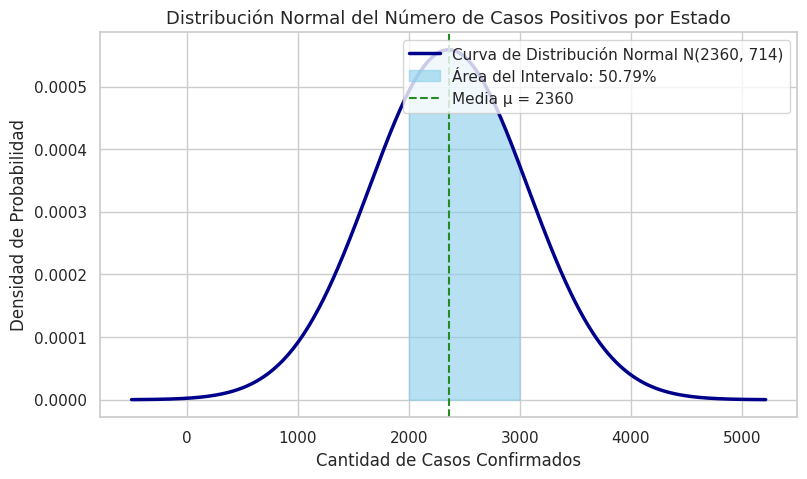

In [9]:
print("===EJERCICIO DE DISTRIBUCIÓN NORMAL INFERENCIAL ===\n")

media_mu = 2360
desv_sigma = 714

# Intervalo analizado
lim_inferior = 2000
lim_superior = 3000

area_hasta_superior = norm.cdf(lim_superior, media_mu, desv_sigma)
area_hasta_inferior = norm.cdf(lim_inferior, media_mu, desv_sigma)
probabilidad_intervalo = area_hasta_superior - area_hasta_inferior

print(f"P(X <= 3000): {area_hasta_superior:.4f}")
print(f"P(X <= 2000): {area_hasta_inferior:.4f}")
print(f"P(2000 <= X <= 3000) = {area_hasta_superior:.4f} - {area_hasta_inferior:.4f}")
print(f"Probabilidad final calculada: {probabilidad_intervalo:.4f} ({probabilidad_intervalo * 100:.2f}%)\n")

x_axis = np.linspace(media_mu - 4*desv_sigma, media_mu + 4*desv_sigma, 1000)
y_axis = norm.pdf(x_axis, media_mu, desv_sigma)

plt.figure(figsize=(9, 5))
plt.plot(x_axis, y_axis, color='darkblue', linewidth=2.5, label='Curva de Distribución Normal N(2360, 714)')
plt.fill_between(x_axis, y_axis, where=(x_axis >= lim_inferior) & (x_axis <= lim_superior),
                 color='skyblue', alpha=0.6, label=f'Área del Intervalo: {probabilidad_intervalo*100:.2f}%')

plt.axvline(media_mu, color='forestgreen', linestyle='--', linewidth=1.5, label=f'Media μ = {media_mu}')

plt.title('Distribución Normal del Número de Casos Positivos por Estado', fontsize=13)
plt.xlabel('Cantidad de Casos Confirmados')
plt.ylabel('Densidad de Probabilidad')
plt.legend(loc='upper right')
plt.show()

===EJERCICIO DE DISTRIBUCIÓN NORMAL INFERENCIAL ===

P(X <= 3000): 0.8150
P(X <= 2000): 0.3071
P(2000 <= X <= 3000) = 0.8150 - 0.3071
 Probabilidad final calculada: 0.5079 (50.79%)



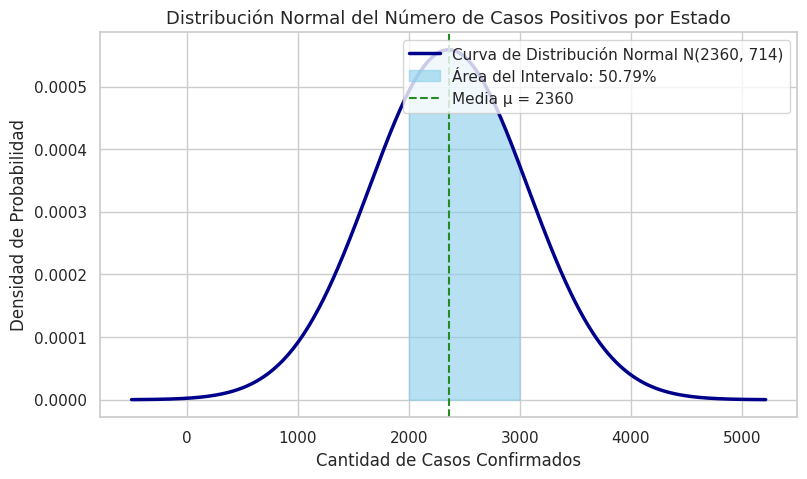

In [10]:
print("===EJERCICIO DE DISTRIBUCIÓN NORMAL INFERENCIAL ===\n")

media_mu = 2360
desv_sigma = 714

lim_inferior = 2000
lim_superior = 3000

area_hasta_superior = norm.cdf(lim_superior, media_mu, desv_sigma)
area_hasta_inferior = norm.cdf(lim_inferior, media_mu, desv_sigma)
probabilidad_intervalo = area_hasta_superior - area_hasta_inferior

print(f"P(X <= 3000): {area_hasta_superior:.4f}")
print(f"P(X <= 2000): {area_hasta_inferior:.4f}")
print(f"P(2000 <= X <= 3000) = {area_hasta_superior:.4f} - {area_hasta_inferior:.4f}")
print(f" Probabilidad final calculada: {probabilidad_intervalo:.4f} ({probabilidad_intervalo * 100:.2f}%)\n")

x_axis = np.linspace(media_mu - 4*desv_sigma, media_mu + 4*desv_sigma, 1000)
y_axis = norm.pdf(x_axis, media_mu, desv_sigma)

plt.figure(figsize=(9, 5))
plt.plot(x_axis, y_axis, color='darkblue', linewidth=2.5, label='Curva de Distribución Normal N(2360, 714)')
plt.fill_between(x_axis, y_axis, where=(x_axis >= lim_inferior) & (x_axis <= lim_superior),
                 color='skyblue', alpha=0.6, label=f'Área del Intervalo: {probabilidad_intervalo*100:.2f}%')

plt.axvline(media_mu, color='forestgreen', linestyle='--', linewidth=1.5, label=f'Media μ = {media_mu}')

plt.title('Distribución Normal del Número de Casos Positivos por Estado', fontsize=13)
plt.xlabel('Cantidad de Casos Confirmados')
plt.ylabel('Densidad de Probabilidad')
plt.legend(loc='upper right')
plt.show()